<a href="https://colab.research.google.com/github/damaske/CV/blob/main/coments1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv
Saving sample.csv to sample.csv
Saving train.csv to train.csv


In [ ]:
import pandas as pd

train  = pd.read_csv("train.csv")
test   = pd.read_csv("test.csv")
sample = pd.read_csv("sample.csv")

print(train.shape, test.shape)
train.head()

(17769, 4) (4797, 3)


,id,feedback,tag,label
0,0,bugun 2 velosipod goturdum ikisinin de tormozu...,NaN,technical_support
1,1,sol pedalda problem var bu veloda,NaN,technical_support
2,2,Oturacağın alt-ön tərəfi çıxıb dəyişilməlidir,Other,technical_support
3,3,velospied kilidə düşmürdü,NaN,technical_support
4,4,Gprs islemir anbara getmelidi,Electrical system,technical_support


In [ ]:
train.info()
train["label"].value_counts()
train["tag"].isna().sum()
print(train["label"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17769 entries, 0 to 17768
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        17769 non-null  int64 
 1   feedback  17769 non-null  object
 2   tag       5265 non-null   object
 3   label     17769 non-null  object
dtypes: int64(1), object(3)
memory usage: 555.4+ KB
label
technical_support    10642
other                 3800
customer_support      3327
Name: count, dtype: int64


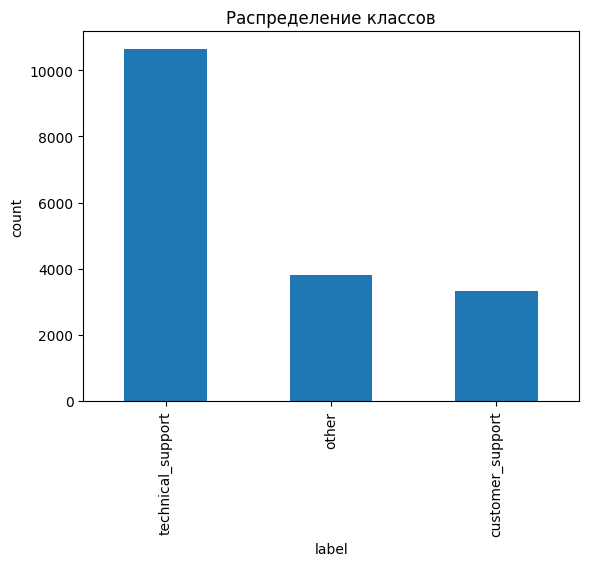

In [ ]:
import matplotlib.pyplot as plt

train["label"].value_counts().plot(kind="bar")
plt.xlabel("label"); plt.ylabel("count")
plt.title("Распределение классов")
plt.show()

In [ ]:
import unicodedata, re

AZ_LETTERS = "abcçdeəfgğhxıijkqlmnoöprsştuüvyz"

RE_URL     = re.compile(r"https?://\S+|www\.\S+")
RE_MENTION = re.compile(r"[@#]\w+")
RE_EMAIL   = re.compile(r"\S+@\S+\.\S+")
RE_NON_AZ = re.compile(r"[^\w\s]", re.UNICODE)
RE_SPACES  = re.compile(r"\s+")

CYR2LAT = {
    "а":"a","б":"b","в":"v","г":"q","ғ":"ğ","д":"d","е":"e","ә":"ə","ж":"j","з":"z",
    "и":"i","ы":"ı","ј":"y","к":"k","ҝ":"g","л":"l","м":"m","н":"n","о":"o","ө":"ö",
    "п":"p","р":"r","с":"s","т":"t","у":"u","ү":"ü","ф":"f","х":"x","һ":"h","ч":"ç",
    "ҹ":"c","ш":"ş","ъ":"","ь":"","э":"e","ю":"yu","я":"ya","ц":"ts","щ":"şç",
}

def normalize_unicode(text: str) -> str:
    return unicodedata.normalize("NFC", text)

def az_lower(text: str) -> str:
    """İ→i, I→ı — обычный .lower() ломает эти буквы."""
    return text.replace("İ", "i").replace("I", "ı").lower()

def cyr_to_lat_if_azeri(text: str) -> str:
    """Транслитерирует СТАРУЮ азербайджанскую кириллицу (1939–1991) в латиницу.
    Обычный современный русский текст (кириллица) НЕ трогаем —
    иначе мы случайно испортим русскоязычные отзывы."""
    # эвристика: если в тексте есть специфичные az-кириллические буквы (ә, ғ, ҝ, ҹ, ө, ү) — это старый азербайджанский
    az_cyrillic_markers = set("әғҝҹөүһ")
    if not (az_cyrillic_markers & set(text.lower())):
        return text  # обычный русский — не трогаем
    out = []
    for ch in text:
        lower = ch.lower()
        if lower in CYR2LAT:
            mapped = CYR2LAT[lower]
            out.append(mapped.capitalize() if ch.isupper() and mapped else mapped)
        else:
            out.append(ch)
    return "".join(out)

def clean_text(text) -> str:
    if not isinstance(text, str):
        return ""
    text = normalize_unicode(text)
    text = cyr_to_lat_if_azeri(text)
    text = az_lower(text)
    text = RE_URL.sub(" ", text)
    text = RE_MENTION.sub(" ", text)
    text = RE_EMAIL.sub(" ", text)
    text = RE_NON_AZ.sub(" ", text)
    text = re.sub(r"\d+", " ", text)
    return RE_SPACES.sub(" ", text).strip()

train["feedback_clean"] = train["feedback"].apply(clean_text)
test["feedback_clean"]  = test["feedback"].apply(clean_text)

In [ ]:
for s in train["feedback"].head(5):
    print(repr(s), "→", repr(clean_text(s)))

'bugun 2 velosipod goturdum ikisinin de tormozu islemir' → 'bugun velosipod goturdum ikisinin de tormozu islemir'
'sol pedalda problem var bu veloda' → 'sol pedalda problem var bu veloda'
'Oturacağın   alt-ön tərəfi çıxıb dəyişilməlidir' → 'oturacağın alt ön tərəfi çıxıb dəyişilməlidir'
'velospied kilidə düşmürdü' → 'velospied kilidə düşmürdü'
'Gprs islemir anbara getmelidi' → 'gprs islemir anbara getmelidi'


In [ ]:
cyrillic_examples = train[train["feedback"].str.contains(r"[а-яА-Я]", regex=True, na=False)]["feedback"].head(5)
for s in cyrillic_examples:
    print(repr(s), "→", repr(clean_text(s)))

'ужасно глучит приложение, не могу спокойно закрыть транспорт уже который день' → 'ужасно глучит приложение не могу спокойно закрыть транспорт уже который день'
'цепь трудный' → 'цепь трудный'
'тормозе не работают адекватно' → 'тормозе не работают адекватно'
'Проблема с педалью.' → 'проблема с педалью'
'Электро мотор не работает!!!' → 'электро мотор не работает'


In [ ]:
import re
emoji_examples = train[train["feedback"].str.contains(r"[\U0001F300-\U0001FAFF]", regex=True, na=False)]["feedback"].head(5)
for s in emoji_examples:
    print(repr(s), "→", repr(clean_text(s)))

'one love 🧡' → 'one love'
'👍👍👍👍👍' → ''
'MÖHTƏŞƏM!👍👍👍' → 'möhtəşəm'
'super👍🏻' → 'super'
'ela pulu cxa bilme pul elave ele tetbiq isdemesin surduyun yoldan coxunu yeri ve pul ode👍🏼' → 'ela pulu cxa bilme pul elave ele tetbiq isdemesin surduyun yoldan coxunu yeri ve pul ode'


In [ ]:
empty_after_clean = (train["feedback_clean"].str.strip() == "").sum()
print("Пустых после очистки:", empty_after_clean)

# посмотрим, какие это строки и какие у них label
train[train["feedback_clean"].str.strip() == ""][["feedback", "tag", "label"]].head(10)

Пустых после очистки: 97


,feedback,tag,label
25,👍👍👍👍👍,NaN,other
257,🔥,NaN,other
343,😊👍,NaN,other
549,2,NaN,other
763,)),NaN,other
775,???,NaN,other
943,0,NaN,other
1098,😛😛,NaN,other
1099,👌👍,NaN,other
1244,4,NaN,other


In [ ]:
# после изменения RE_NON_AZ — пересоздать колонки
train["feedback_clean"] = train["feedback"].apply(clean_text)
test["feedback_clean"]  = test["feedback"].apply(clean_text)

# проверка: сколько теперь пустых после очистки
empty_mask = train["feedback_clean"].str.strip() == ""
print(train[empty_mask]["label"].value_counts())

label
other                96
technical_support     1
Name: count, dtype: int64


In [ ]:
!pip install langid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941171 sha256=20d28c438cda8cff4dacef040f43185b93bf2122d1dedd4fd7f64a1fe9204cb0
  Stored in directory: /root/.cache/pip/wheels/3c/bc/9d/266e27289b9019680d65d9b608c37bff1eff565b001c977ec5
Successfully built langid


In [ ]:
import langid

langid.set_languages(['az', 'ru', 'en', 'tr'])

def detect_lang(text):
    if not text.strip():
        return "unknown"
    lang, _ = langid.classify(text)
    return lang

train["lang"] = train["feedback_clean"].apply(detect_lang)
test["lang"]  = test["feedback_clean"].apply(detect_lang)

train["lang"].value_counts()

,count
lang,
az,7257
en,4432
tr,3509
ru,2474
unknown,97


In [ ]:
train[train["lang"] == "tr"]["feedback_clean"].sample(10, random_state=42)

,feedback_clean
16040,lsçs
1753,tutuldu yolun ortasında
11125,qaz ishlemir pedal ssinib
14959,ön dinama işığı yanmır
2486,nese elektrik xodlanmir
6897,sükan laxlıyır
6139,rol nasazdir temire ehtiyaci var
7160,nasazlıq
2855,zibil kimi gediş
14095,blok oldu


In [ ]:
train["lang"] = train["lang"].replace("tr", "az")
test["lang"]  = test["lang"].replace("tr", "az")

print(train["lang"].value_counts())

lang
az         10766
en          4432
ru          2474
unknown       97
Name: count, dtype: int64


In [ ]:
train[train["lang"] == "en"]["feedback_clean"].sample(10, random_state=42)

,feedback_clean
9951,its broken and add more scooters
3272,velo was bloked
16290,rulda problem var idare elemek tehlukelidir
3709,problem bahadi
1274,steering is way too stiff
11444,super
15262,i want end my trip but i cant it says that veh...
9160,rol əyri idi
590,pis xoddanmadi
9561,impossible to turn the pedals especially with ...


In [ ]:
train["tag_filled"] = train["tag"].fillna("no_tag")
test["tag_filled"]  = test["tag"].fillna("no_tag")

train["text_full"] = train["lang"] + " " + train["tag_filled"] + " " + train["feedback_clean"]
test["text_full"]  = test["lang"] + " " + test["tag_filled"] + " " + test["feedback_clean"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train["text_full"], train["label"],
    test_size=0.2, random_state=42, stratify=train["label"]
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)   # fit только на train
X_val_vec   = vectorizer.transform(X_val)          # только transform

In [ ]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
baseline.fit(X_train_vec, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    loss_function="MultiClass", random_seed=42, verbose=100
)
cat_model.fit(X_train_vec, y_train, eval_set=(X_val_vec, y_val))

0:	learn: 1.0757616	test: 1.0757028	best: 1.0757028 (0)	total: 1.08s	remaining: 9m
100:	learn: 0.7056450	test: 0.7047905	best: 0.7047905 (100)	total: 33.5s	remaining: 2m 12s
200:	learn: 0.6409844	test: 0.6419986	best: 0.6419986 (200)	total: 56.5s	remaining: 1m 24s
300:	learn: 0.6006976	test: 0.6059677	best: 0.6059677 (300)	total: 1m 20s	remaining: 52.9s
400:	learn: 0.5730675	test: 0.5830655	best: 0.5830655 (400)	total: 1m 43s	remaining: 25.5s
499:	learn: 0.5548737	test: 0.5685569	best: 0.5685569 (499)	total: 2m 6s	remaining: 0us

bestTest = 0.5685569341
bestIteration = 499



CatBoostClassifier(depth=6, iterations=500, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

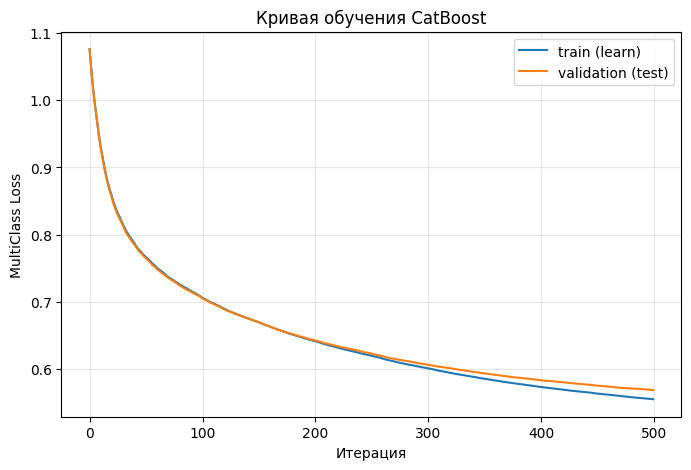

In [ ]:
import matplotlib.pyplot as plt

results = cat_model.get_evals_result()

train_loss = results["learn"]["MultiClass"]
val_loss   = results["validation"]["MultiClass"]

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="train (learn)")
plt.plot(val_loss, label="validation (test)")
plt.xlabel("Итерация")
plt.ylabel("MultiClass Loss")
plt.title("Кривая обучения CatBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, log_loss


pred_lr = baseline.classes_[baseline.predict_proba(X_val_vec).argmax(axis=1)]
print(classification_report(y_val, pred_lr))
print(confusion_matrix(y_val, pred_lr))

                   precision    recall  f1-score   support

 customer_support       0.76      0.83      0.79       665
            other       0.76      0.89      0.82       760
technical_support       0.94      0.85      0.90      2129

         accuracy                           0.86      3554
        macro avg       0.82      0.86      0.84      3554
     weighted avg       0.87      0.86      0.86      3554

[[ 553   48   64]
 [  35  678   47]
 [ 140  170 1819]]


In [ ]:
import numpy as np

def predict_with_thresholds(proba, thresholds, classes):
    idx = (proba / np.asarray(thresholds)[None, :]).argmax(axis=1)
    return classes[idx]

def tune_thresholds(proba, y_true, classes, n_rounds=5, grid=None):
    if grid is None:
        grid = np.linspace(0.02, 1.5, 75)
    n_classes = proba.shape[1]
    thresholds = np.ones(n_classes)
    best_f1 = f1_score(y_true, predict_with_thresholds(proba, thresholds, classes), average="macro")
    for r in range(n_rounds):
        improved = False
        for k in range(n_classes):
            for t in grid:
                cand = thresholds.copy(); cand[k] = t
                f1 = f1_score(y_true, predict_with_thresholds(proba, cand, classes), average="macro")
                if f1 > best_f1 + 1e-6:
                    best_f1, thresholds, improved = f1, cand, True
        if not improved:
            break
    return thresholds, best_f1

proba_val = baseline.predict_proba(X_val_vec)
classes = baseline.classes_
thresholds, best_val_f1 = tune_thresholds(proba_val, y_val, classes)
print("Пороги:", dict(zip(classes, thresholds)))
print("F1-macro после подбора порогов (val):", best_val_f1)

Пороги: {'customer_support': np.float64(1.5), 'other': np.float64(1.48), 'technical_support': np.float64(0.88)}
F1-macro после подбора порогов (val): 0.8587933806722697


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    baseline,
    X_train_vec,   # тот же TF-IDF, что использовали раньше
    y_train,
    cv=5,
    scoring="f1_macro"
)

print("F1-macro по фолдам:", scores)
print("Среднее:", scores.mean())
print("Разброс (std):", scores.std())

F1-macro по фолдам: [0.8431811  0.83932081 0.83112417 0.81664427 0.8424094 ]
Среднее: 0.8345359516802299
Разброс (std): 0.00991339585581292


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {"C": [0.1, 0.5, 1, 2, 5, 10]}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    params,
    cv=5,
    scoring="f1_macro"
)
grid.fit(X_train_vec, y_train)

print("Лучший C:", grid.best_params_)
print("Лучший F1-macro (CV):", grid.best_score_)

Лучший C: {'C': 10}
Лучший F1-macro (CV): 0.8445175561395792


In [ ]:
params = {"C": [10, 20, 50, 100]}

grid2 = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    params,
    cv=5,
    scoring="f1_macro"
)
grid2.fit(X_train_vec, y_train)

print("Лучший C:", grid2.best_params_)
print("Лучший F1-macro (CV):", grid2.best_score_)

Лучший C: {'C': 10}
Лучший F1-macro (CV): 0.8445175561395792


In [ ]:
# финальная модель с лучшим C
baseline_tuned = LogisticRegression(C=10, max_iter=1000, class_weight="balanced", random_state=42)
baseline_tuned.fit(X_train_vec, y_train)

# проверяем F1-macro на нашем исходном val split (не CV, а конкретный split, с которым работали раньше)
pred = baseline_tuned.classes_[baseline_tuned.predict_proba(X_val_vec).argmax(axis=1)]
print("F1-macro (val, без порогов):", f1_score(y_val, pred, average="macro"))

# пересчитываем пороги под новую модель
proba_val = baseline_tuned.predict_proba(X_val_vec)
classes = baseline_tuned.classes_
thresholds, best_val_f1 = tune_thresholds(proba_val, y_val, classes)
print("Пороги:", dict(zip(classes, thresholds)))
print("F1-macro после подбора порогов (val):", best_val_f1)

F1-macro (val, без порогов): 0.8631559799929721
Пороги: {'customer_support': np.float64(1.26), 'other': np.float64(1.1), 'technical_support': np.float64(1.0)}
F1-macro после подбора порогов (val): 0.8648434630606253


In [ ]:
# Векторизатор — заново, но уже на ВСЁМ train.csv
vectorizer_final = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_full_vec = vectorizer_final.fit_transform(train["text_full"])

# Модель — с лучшим C=10
final_model = LogisticRegression(C=10, max_iter=1000, class_weight="balanced", random_state=42)
final_model.fit(X_full_vec, train["label"])

LogisticRegression(C=10, class_weight='balanced', max_iter=1000,
                   random_state=42)

In [ ]:
thresholds_final = {'customer_support': 1.26, 'other': 1.10, 'technical_support': 1.00}
classes_final = final_model.classes_
thresholds_array = np.array([thresholds_final[c] for c in classes_final])

In [ ]:
X_test_vec = vectorizer_final.transform(test["text_full"])   # только transform!
proba_test = final_model.predict_proba(X_test_vec)
test_pred = predict_with_thresholds(proba_test, thresholds_array, classes_final)

In [ ]:
submission = pd.DataFrame({"id": test["id"], "label": test_pred})

assert submission["id"].is_unique
assert submission.shape[0] == test.shape[0]
assert set(submission["label"]) <= {"technical_support", "customer_support", "other"}

submission.to_csv("submission.csv", index=False)

from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pd.read_csv("submission.csv").head()

,id,label
0,17769,other
1,17770,technical_support
2,17771,technical_support
3,17772,customer_support
4,17773,technical_support
